In [2]:

from mGST.low_level_jit import cost_function_jax_mps
from mGST.utility_functions_comparisons import get_compressed_rep_from_mgst_output, get_kraus_psd_from_mgst

from iqm.benchmarks.compressive_gst.compressive_gst import GSTConfiguration
from mGST.utility_functions_comparisons import get_full_mgst_parameters_from_configuration, create_4q_gst_config
from mGST.visualization import plot_wall_time
from mGST.automatic_diff import automatic_gradient, hvp
import jax.numpy as jnp
import jax

backend = "iqmfakeapollo"
data_path = "../data/"

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Goal

1. See the dependence on the cost function with respect to the kraus rank. Similar for gradient and Hessian

Can do this for 4Q GST alone.

In [3]:
dim_4q = 2**4
Q4_GST = create_4q_gst_config(kraus_rank=dim_4q**2)

kraus_tensor_mgst_4q, kraus_mgst_4q, povm_mgst_4q, state_mgst_4q, prob_matrix_4q, indices_list_4q = get_full_mgst_parameters_from_configuration(
    Q4_GST, backend, only_jax_variables=True
)

_, povm_psd_4q, state_psd_4q = get_compressed_rep_from_mgst_output(kraus_mgst_4q, povm_mgst_4q, state_mgst_4q, kraus_rank=1, state_rank=dim_4q, povm_rank=dim_4q)

kraus_tensor_4q_rank1 = get_kraus_psd_from_mgst(kraus_mgst_4q, rank=1)
kraus_tensor_4q_rank2 = get_kraus_psd_from_mgst(kraus_mgst_4q, rank=2)
kraus_tensor_4q_rank4 = get_kraus_psd_from_mgst(kraus_mgst_4q, rank=4)
kraus_tensor_4q_rank8 = get_kraus_psd_from_mgst(kraus_mgst_4q, rank=8)
kraus_tensor_4q_rank16 = get_kraus_psd_from_mgst(kraus_mgst_4q, rank=16)
kraus_tensor_4q_full = get_kraus_psd_from_mgst(kraus_mgst_4q, rank=dim_4q**2)

2025-10-07 14:01:10,889 - iqm.benchmarks.logging_config - INFO - Now generating 2000 random GST circuits...
2025-10-07 14:01:11,798 - iqm.benchmarks.logging_config - INFO - Will transpile all 2000 circuits according to fixed physical layout
2025-10-07 14:01:11,798 - iqm.benchmarks.logging_config - INFO - Transpiling for backend IQMFakeApolloBackend with optimization level 0, sabre routing method all circuits
2025-10-07 14:01:15,294 - iqm.benchmarks.logging_config - INFO - Submitting batch with 2000 circuits corresponding to qubits [0, 1, 3, 4]
2025-10-07 14:01:15,303 - iqm.benchmarks.logging_config - INFO - Now executing the corresponding circuit batch
2025-10-07 14:01:15,364 - iqm.benchmarks.logging_config - INFO - Retrieving all counts
INFO:2025-10-07 14:01:36,160:jax._src.xla_bridge:927: Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
2025-10-07 14:01:36,160 - jax._src.xla_bridge - INFO - Unable to initialize backend 'rocm': m

In [4]:
kraus_tensor_4q_full.shape

(9, 256, 16, 16)

# Cost function

In [5]:
input_cost_fn = {
    "povm_psd": povm_psd_4q,
    "state_psd": state_psd_4q,
    "prob_matrix": prob_matrix_4q,
    "indices_list": indices_list_4q,
}

fn_kraus_jit = lambda x: cost_function_jax_mps(kraus_tensor = x, jit=True, **input_cost_fn)
fn_kraus_no_jit = lambda x: cost_function_jax_mps(kraus_tensor = x, jit=False, **input_cost_fn)

In [6]:
# Run the JIT-ted cost function once to compile it
cost_rank1 = fn_kraus_jit(kraus_tensor_4q_rank1)

at iteration 0 the new count changed to: 1
at iteration 1 the new count changed to: 2
at iteration 10 the new count changed to: 3
at iteration 91 the new count changed to: 4
at iteration 242 the new count changed to: 5
at iteration 393 the new count changed to: 6
at iteration 544 the new count changed to: 7
at iteration 696 the new count changed to: 8
at iteration 848 the new count changed to: 9
at iteration 1000 the new count changed to: 10
at iteration 1166 the new count changed to: 11
at iteration 1332 the new count changed to: 12
at iteration 1499 the new count changed to: 13
at iteration 1666 the new count changed to: 14
at iteration 1833 the new count changed to: 15


In [7]:
cost_rank2 = fn_kraus_jit(kraus_tensor_4q_rank2)

at iteration 0 the new count changed to: 16
at iteration 1 the new count changed to: 17
at iteration 10 the new count changed to: 18
at iteration 91 the new count changed to: 19
at iteration 242 the new count changed to: 20
at iteration 393 the new count changed to: 21
at iteration 544 the new count changed to: 22
at iteration 696 the new count changed to: 23
at iteration 848 the new count changed to: 24
at iteration 1000 the new count changed to: 25
at iteration 1166 the new count changed to: 26
at iteration 1332 the new count changed to: 27
at iteration 1499 the new count changed to: 28
at iteration 1666 the new count changed to: 29
at iteration 1833 the new count changed to: 30


In [8]:
cost_rank4 = fn_kraus_jit(kraus_tensor_4q_rank4)

at iteration 0 the new count changed to: 31
at iteration 1 the new count changed to: 32
at iteration 10 the new count changed to: 33
at iteration 91 the new count changed to: 34
at iteration 242 the new count changed to: 35
at iteration 393 the new count changed to: 36
at iteration 544 the new count changed to: 37
at iteration 696 the new count changed to: 38
at iteration 848 the new count changed to: 39
at iteration 1000 the new count changed to: 40
at iteration 1166 the new count changed to: 41
at iteration 1332 the new count changed to: 42
at iteration 1499 the new count changed to: 43
at iteration 1666 the new count changed to: 44
at iteration 1833 the new count changed to: 45


In [9]:
cost_rank8 = fn_kraus_jit(kraus_tensor_4q_rank8)

at iteration 0 the new count changed to: 46
at iteration 1 the new count changed to: 47
at iteration 10 the new count changed to: 48
at iteration 91 the new count changed to: 49
at iteration 242 the new count changed to: 50
at iteration 393 the new count changed to: 51
at iteration 544 the new count changed to: 52
at iteration 696 the new count changed to: 53
at iteration 848 the new count changed to: 54
at iteration 1000 the new count changed to: 55
at iteration 1166 the new count changed to: 56
at iteration 1332 the new count changed to: 57
at iteration 1499 the new count changed to: 58
at iteration 1666 the new count changed to: 59
at iteration 1833 the new count changed to: 60


In [10]:
cost_rank16 = fn_kraus_jit(kraus_tensor_4q_rank16)

at iteration 0 the new count changed to: 61
at iteration 1 the new count changed to: 62
at iteration 10 the new count changed to: 63
at iteration 91 the new count changed to: 64
at iteration 242 the new count changed to: 65
at iteration 393 the new count changed to: 66
at iteration 544 the new count changed to: 67
at iteration 696 the new count changed to: 68
at iteration 848 the new count changed to: 69
at iteration 1000 the new count changed to: 70
at iteration 1166 the new count changed to: 71
at iteration 1332 the new count changed to: 72
at iteration 1499 the new count changed to: 73
at iteration 1666 the new count changed to: 74
at iteration 1833 the new count changed to: 75


In [11]:
cost_rank256 = fn_kraus_jit(kraus_tensor_4q_full)

at iteration 0 the new count changed to: 76
at iteration 1 the new count changed to: 77
at iteration 10 the new count changed to: 78
at iteration 91 the new count changed to: 79
at iteration 242 the new count changed to: 80
at iteration 393 the new count changed to: 81
at iteration 544 the new count changed to: 82
at iteration 696 the new count changed to: 83
at iteration 848 the new count changed to: 84
at iteration 1000 the new count changed to: 85
at iteration 1166 the new count changed to: 86
at iteration 1332 the new count changed to: 87
at iteration 1499 the new count changed to: 88
at iteration 1666 the new count changed to: 89
at iteration 1833 the new count changed to: 90


## timing

In [14]:
timing_cost_fn_rank_1 = %timeit -o fn_kraus_jit(kraus_tensor_4q_rank1)
timing_cost_fn_rank_2 = %timeit -o fn_kraus_jit(kraus_tensor_4q_rank2)
timing_cost_fn_rank_4 = %timeit -o fn_kraus_jit(kraus_tensor_4q_rank4)
timing_cost_fn_rank_8 = %timeit -o fn_kraus_jit(kraus_tensor_4q_rank8)

207 ms ± 2.66 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
264 ms ± 2.96 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
386 ms ± 2.31 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
642 ms ± 14.5 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [ ]:
timing_cost_fn_rank_8 = %timeit -o fn_kraus_jit(kraus_tensor_4q_rank8)

In [15]:
timing_cost_fn_rank_1_no_jit = %timeit -o fn_kraus_no_jit(kraus_tensor_4q_rank1)
timing_cost_fn_rank_2_no_jit = %timeit -o fn_kraus_no_jit(kraus_tensor_4q_rank2)
timing_cost_fn_rank_4_no_jit = %timeit -o fn_kraus_no_jit(kraus_tensor_4q_rank4)
timing_cost_fn_rank_8_no_jit = %timeit -o fn_kraus_no_jit(kraus_tensor_4q_rank8)

2.8 s ± 30.3 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
2.89 s ± 67.4 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
2.92 s ± 32.9 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
3.13 s ± 79 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


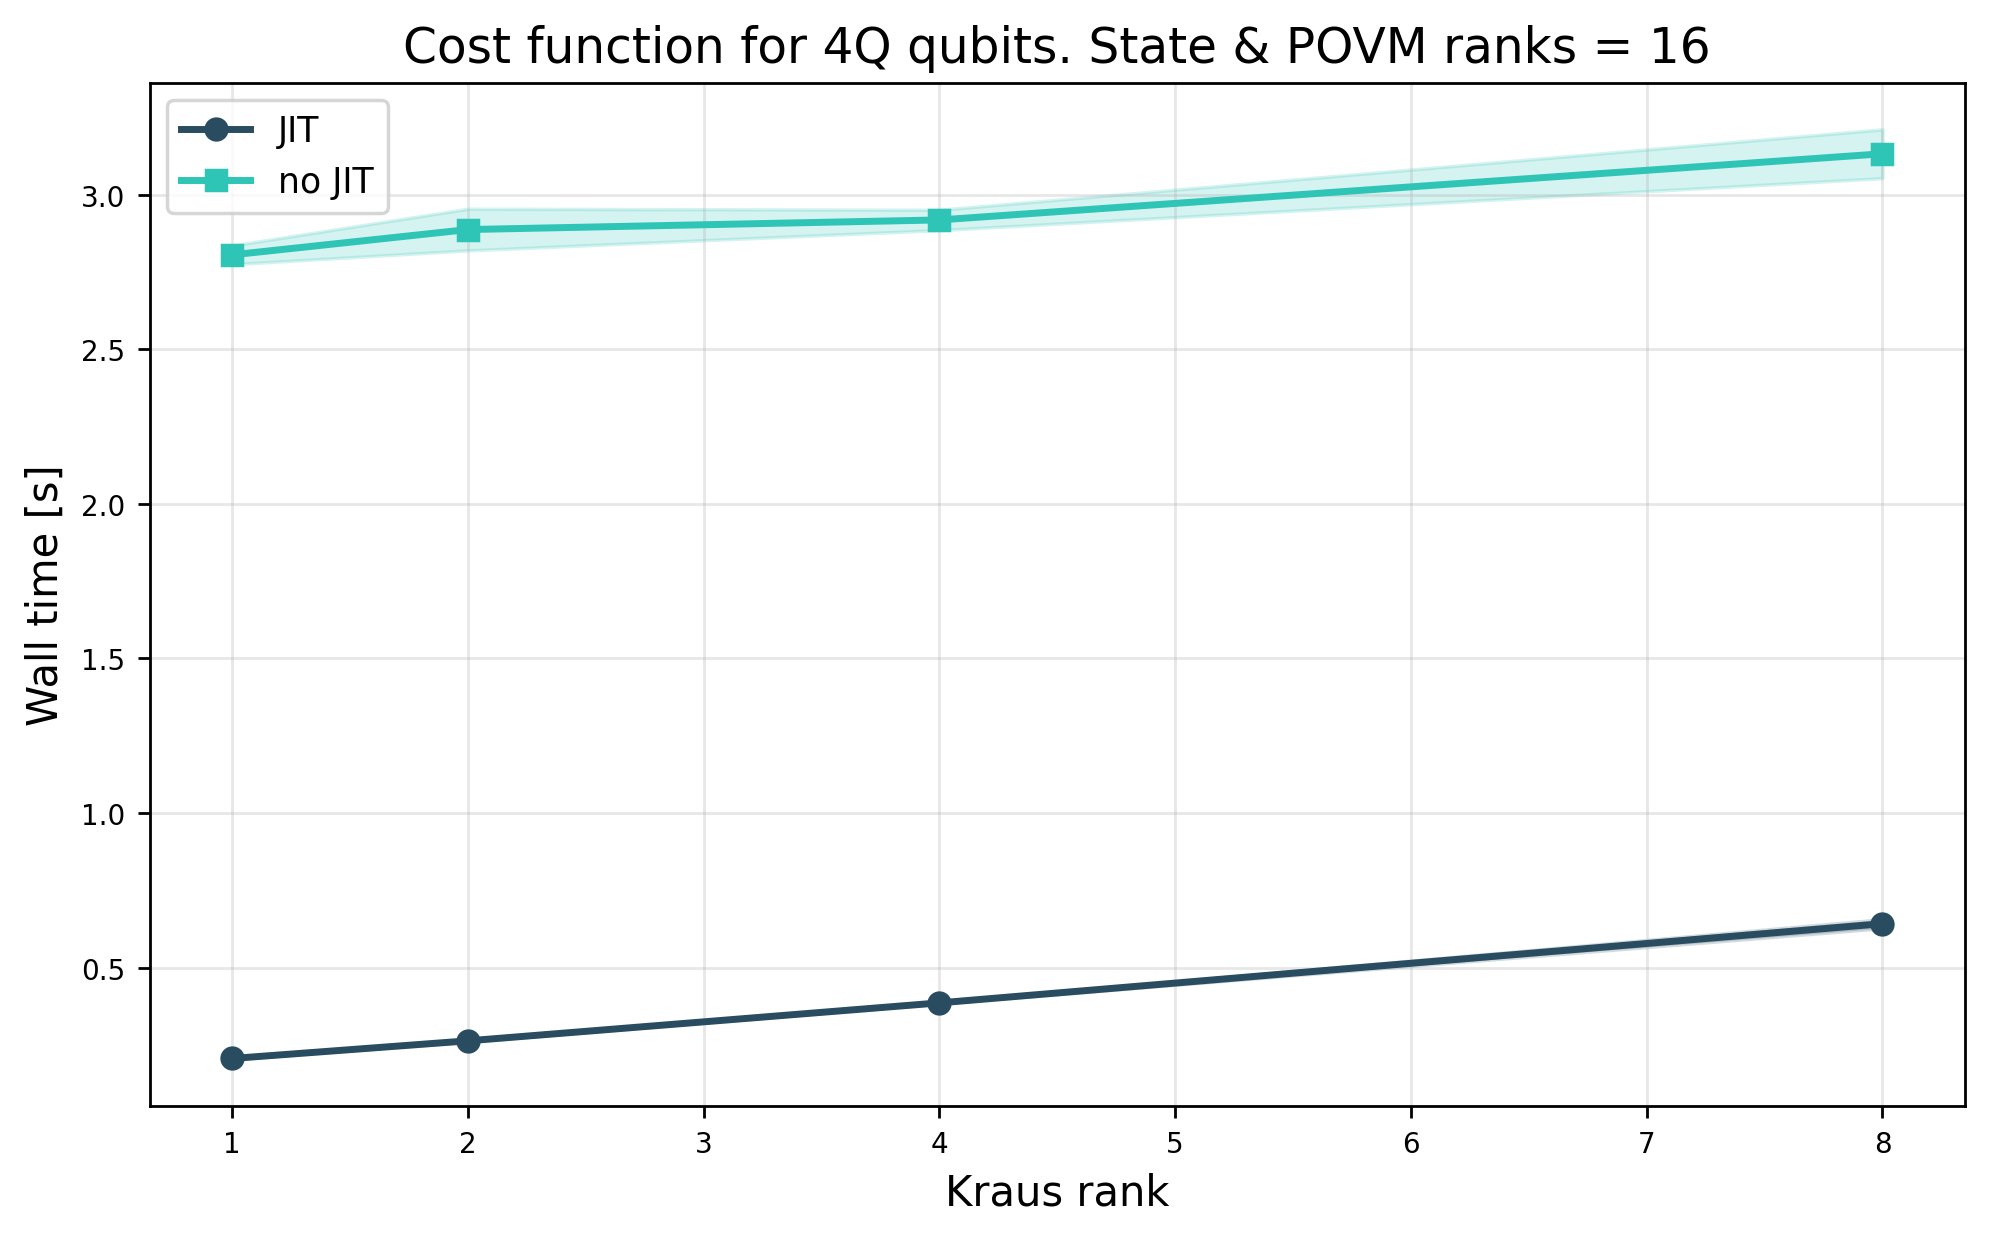

In [18]:

timings_cost_fn = [timing_cost_fn_rank_1, timing_cost_fn_rank_2, timing_cost_fn_rank_4, timing_cost_fn_rank_8]
tuples_cost_fn = [(time.average, time.stdev) for time in timings_cost_fn]

timings_cost_fn_no_jit = [timing_cost_fn_rank_1_no_jit, timing_cost_fn_rank_2_no_jit, timing_cost_fn_rank_4_no_jit, timing_cost_fn_rank_8_no_jit]
tuples_cost_fn_no_jit = [(time.average, time.stdev) for time in timings_cost_fn_no_jit]


cost_fn_times = {
    "JIT": tuples_cost_fn,
    "no JIT": tuples_cost_fn_no_jit,
}


ranks = [1, 2, 4, 8]
xlabel = "Kraus rank"
title = "Cost function for 4Q qubits. State & POVM ranks = 16"

plot_wall_time(cost_fn_times, ranks, logscale=None, xlabel=xlabel, title=title)